In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:\Master Of Data Science And AI\Capstone\model\data\dataset1\carton_1.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Yasitha\AppData\Local\Temp\ipykernel_25892\220639320.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("D:\Master Of Data Science And AI\Capstone\model\data\dataset1\carton_1.csv")


,Time,Reading ID,Humidity,Temperature,MQ139,TVOC,eCO2,Detector,Status
0,0:00:00,1,43.5,21.3,98,0,400,OFF,0
1,0:00:01,2,43.5,21.3,97,0,400,OFF,0
2,0:00:02,3,43.6,21.4,97,0,400,OFF,0
3,0:00:03,4,43.6,21.4,97,0,400,OFF,0
4,0:00:04,5,43.7,21.4,98,0,400,OFF,0


In [3]:
df.columns

Index(['Time', 'Reading ID', 'Humidity', 'Temperature', 'MQ139', 'TVOC',
       'eCO2', 'Detector', 'Status'],
      dtype='object')

In [4]:
features = ["Temperature", "Humidity", "TVOC", "eCO2", "MQ139"]

df_clean = df[features + ["Status"]]

df_clean.head()

,Temperature,Humidity,TVOC,eCO2,MQ139,Status
0,21.3,43.5,0,400,98,0
1,21.3,43.5,0,400,97,0
2,21.4,43.6,0,400,97,0
3,21.4,43.6,0,400,97,0
4,21.4,43.7,0,400,98,0


In [5]:
df_clean["Status"].value_counts()

Status
1    180
2     99
0     51
Name: count, dtype: int64

In [6]:
files = [
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\carton_1.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\carton_2.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\clothing_1.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\clothing_2.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\electrical_1.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\electrical_2.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\electrical_3.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\electrical_4.csv"
]

dfs = []

for f in files:
    temp = pd.read_csv(f)
    temp["scenario"] = f
    dfs.append(temp)

df_all = pd.concat(dfs, ignore_index=True)

df_all.head()

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Yasitha\AppData\Local\Temp\ipykernel_25892\739366347.py:2: SyntaxWarning: invalid escape sequence '\M'
  "D:\Master Of Data Science And AI\Capstone\model\data\dataset1\carton_1.csv",
C:\Users

,Time,Reading ID,Humidity,Temperature,MQ139,TVOC,eCO2,Detector,Status,scenario,Reading ID#,Humidity%,Humidity,Temperature,MQ139,TVOC,eCO2,Detector,Temperature
0,0:00:00,1.0,43.5,21.3,98.0,0.0,400.0,OFF,0,D:\Master Of Data Science And AI\Capstone\mode...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0:00:01,2.0,43.5,21.3,97.0,0.0,400.0,OFF,0,D:\Master Of Data Science And AI\Capstone\mode...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0:00:02,3.0,43.6,21.4,97.0,0.0,400.0,OFF,0,D:\Master Of Data Science And AI\Capstone\mode...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0:00:03,4.0,43.6,21.4,97.0,0.0,400.0,OFF,0,D:\Master Of Data Science And AI\Capstone\mode...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0:00:04,5.0,43.7,21.4,98.0,0.0,400.0,OFF,0,D:\Master Of Data Science And AI\Capstone\mode...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
features = ["Temperature", "Humidity", "TVOC", "eCO2", "MQ139"]

df_clean = df_all[features + ["Status"]]

In [8]:
df_clean["Status"].value_counts()

Status
1    6665
0    2831
2    2301
Name: count, dtype: int64

In [9]:
features = ["Temperature","Humidity","TVOC","eCO2","MQ139"]

df_model = df_clean.copy()

# convert to numeric
for col in features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# fill missing values
df_model[features] = df_model[features].ffill().bfill()

# check again
df_model[features].isna().sum()

Temperature    0
Humidity       0
TVOC           0
eCO2           0
MQ139          0
dtype: int64

In [10]:
df_normal = df_model[df_model["Status"] == 0]
len(df_normal)

2831

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_normal = scaler.fit_transform(df_normal[features])

In [12]:
import numpy as np

window_size = 60

X_windows = []
y_windows = []

for i in range(len(X_normal) - window_size):
    
    X_windows.append(X_normal[i:i+window_size])
    
    y_windows.append(X_normal[i+window_size])

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

print("X shape:", X_windows.shape)
print("Y shape:", y_windows.shape)

X shape: (2771, 60, 5)
Y shape: (2771, 5)


In [13]:
# =========================================
# 1. Imports
# =========================================
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

In [14]:
# =========================================
# 2. Convert numpy arrays to PyTorch tensors
# =========================================
X_tensor = torch.tensor(X_windows, dtype=torch.float32)  
y_tensor = torch.tensor(y_windows, dtype=torch.float32)  

dataset = TensorDataset(X_tensor, y_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

Train samples: 2216
Val samples: 555


In [15]:
# =========================================
# 3. TCN Building Blocks
# =========================================
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNForecaster(nn.Module):
    def __init__(self, input_size, channels=[32, 64], kernel_size=3, dropout=0.2, output_size=5):
        super().__init__()

        layers = []
        in_channels = input_size

        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout
                )
            )
            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], output_size)

    def forward(self, x):
        
        x = x.transpose(1, 2)   
        y = self.tcn(x)         
        y = y[:, :, -1]        
        y = self.fc(y)          
        return y

In [16]:
# =========================================
# 4. Initialize model
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TCNForecaster(
    input_size=5,     
    channels=[32, 64],
    kernel_size=3,
    dropout=0.2,
    output_size=5
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Using device:", device)

TCNForecaster(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(5, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (net): Sequential(
        (0): Conv1d(5, 32, kernel_size=(3,), stride=(1,), padding=(2,))
        (1): Chomp1d()
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
        (5): Chomp1d()
        (6): ReLU()
        (7): Dropout(p=0.2, inplace=False)
      )
      (downsample): Conv1d(5, 32, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (relu1): Re

In [17]:
# =========================================
# 5. Training loop
# =========================================
num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

Epoch [1/30] | Train Loss: 0.335582 | Val Loss: 0.104728
Epoch [2/30] | Train Loss: 0.118531 | Val Loss: 0.165245
Epoch [3/30] | Train Loss: 0.092704 | Val Loss: 0.022936
Epoch [4/30] | Train Loss: 0.072725 | Val Loss: 0.033121
Epoch [5/30] | Train Loss: 0.103787 | Val Loss: 0.024683
Epoch [6/30] | Train Loss: 0.069657 | Val Loss: 0.023587
Epoch [7/30] | Train Loss: 0.067392 | Val Loss: 0.050430
Epoch [8/30] | Train Loss: 0.083299 | Val Loss: 0.032441
Epoch [9/30] | Train Loss: 0.074085 | Val Loss: 0.037634
Epoch [10/30] | Train Loss: 0.066237 | Val Loss: 0.043995
Epoch [11/30] | Train Loss: 0.065670 | Val Loss: 0.012830
Epoch [12/30] | Train Loss: 0.066854 | Val Loss: 0.015644
Epoch [13/30] | Train Loss: 0.058397 | Val Loss: 0.015315
Epoch [14/30] | Train Loss: 0.061614 | Val Loss: 0.042446
Epoch [15/30] | Train Loss: 0.066103 | Val Loss: 0.015604
Epoch [16/30] | Train Loss: 0.061879 | Val Loss: 0.016406
Epoch [17/30] | Train Loss: 0.060261 | Val Loss: 0.015918
Epoch [18/30] | Train L

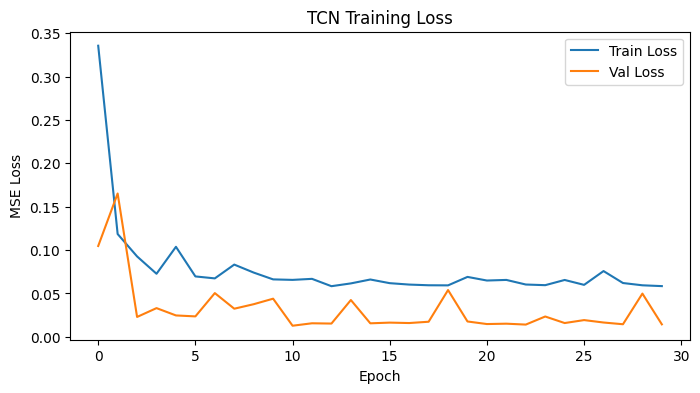

In [18]:
# =========================================
# 6. Plot training history
# =========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TCN Training Loss")
plt.legend()
plt.show()

In [19]:
# =========================================
# 7. Save model
# =========================================
import os
os.makedirs("models/dataset1", exist_ok=True)
torch.save(model.state_dict(), "models/dataset1/tcn_dataset1_forecaster.pt")
print("Model saved to dataset1 directory.")

Model saved to dataset1 directory.


In [20]:
model.eval()

with torch.no_grad():
    X_all = torch.tensor(X_windows, dtype=torch.float32).to(device)
    y_true = torch.tensor(y_windows, dtype=torch.float32).to(device)
    y_pred = model(X_all)

residuals = torch.abs(y_pred - y_true).cpu().numpy()
residual_score = residuals.mean(axis=1)

print("Residual shape:", residuals.shape)
print("Residual score shape:", residual_score.shape)

Residual shape: (2771, 5)
Residual score shape: (2771,)


In [21]:
features = ["Temperature", "Humidity", "TVOC", "eCO2", "MQ139"]


df_full = df_model.copy()

X_full = scaler.transform(df_full[features])

window_size = 60
X_full_windows = []
y_full_windows = []
status_full = []

for i in range(len(X_full) - window_size):
    X_full_windows.append(X_full[i:i+window_size])
    y_full_windows.append(X_full[i+window_size])
    status_full.append(df_full["Status"].iloc[i+window_size])

X_full_windows = np.array(X_full_windows, dtype=np.float32)
y_full_windows = np.array(y_full_windows, dtype=np.float32)
status_full = np.array(status_full)

print(X_full_windows.shape)
print(y_full_windows.shape)
print(status_full.shape)

(11737, 60, 5)
(11737, 5)
(11737,)


In [22]:
model.eval()

with torch.no_grad():
    X_test = torch.tensor(X_full_windows, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_full_windows, dtype=torch.float32).to(device)
    y_hat = model(X_test)

full_residuals = torch.abs(y_hat - y_test).cpu().numpy()
full_residual_score = full_residuals.mean(axis=1)

print(full_residual_score.shape)

(11737,)


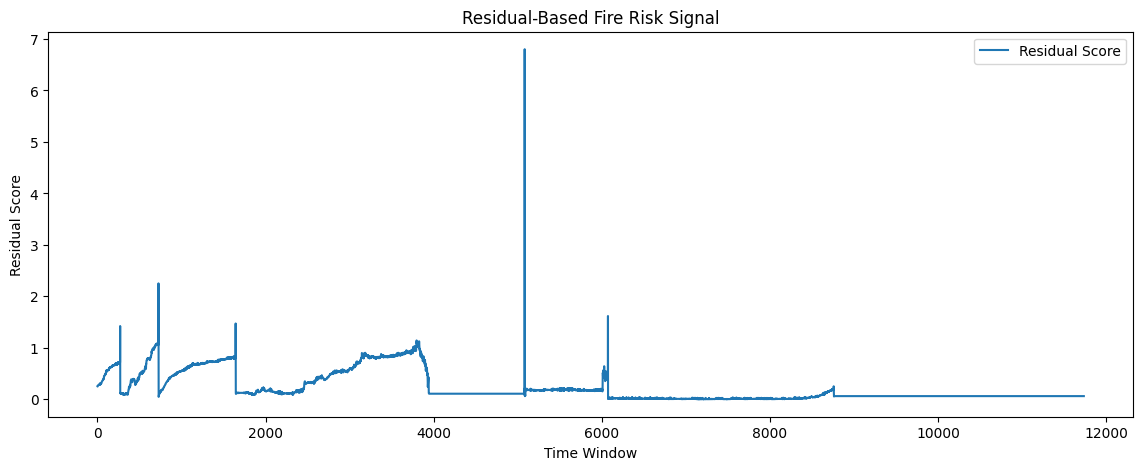

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(full_residual_score, label="Residual Score")
plt.title("Residual-Based Fire Risk Signal")
plt.xlabel("Time Window")
plt.ylabel("Residual Score")
plt.legend()
plt.show()

In [24]:
import pandas as pd

df_result = pd.DataFrame({
    "ResidualScore": full_residual_score,
    "Status": status_full
})

print(df_result.groupby("Status")["ResidualScore"].describe())

         count      mean       std       min       25%       50%       75%  \
Status                                                                       
0       2780.0  0.030175  0.147475  0.002210  0.007817  0.011938  0.020308   
1       6656.0  0.173544  0.166000  0.015928  0.062531  0.109288  0.184006   
2       2301.0  0.611974  0.313390  0.062531  0.534830  0.725187  0.828464   

             max  
Status            
0       6.801079  
1       1.016593  
2       1.144003  


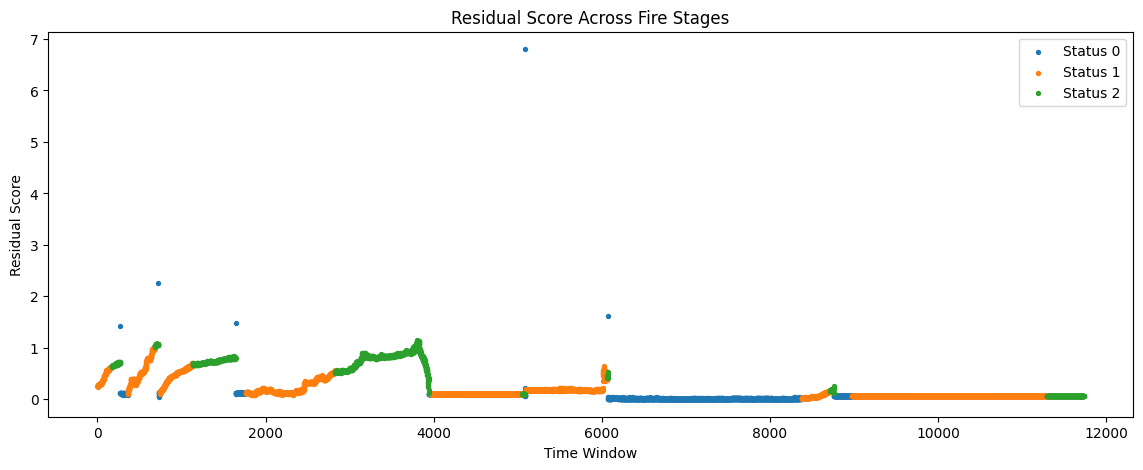

In [25]:
plt.figure(figsize=(14,5))
for s in [0, 1, 2]:
    idx = np.where(status_full == s)[0]
    plt.scatter(idx, full_residual_score[idx], label=f"Status {s}", s=8)

plt.title("Residual Score Across Fire Stages")
plt.xlabel("Time Window")
plt.ylabel("Residual Score")
plt.legend()
plt.show()

In [26]:
full_residual_score = np.clip(full_residual_score, 0, 2)

In [27]:
df_result.groupby("Status")["ResidualScore"].mean()

Status
0    0.030175
1    0.173544
2    0.611974
Name: ResidualScore, dtype: float32

In [28]:
df_result.groupby("Status")["ResidualScore"].std()

Status
0    0.147475
1    0.166000
2    0.313390
Name: ResidualScore, dtype: float32

Defaulting to user installation because normal site-packages is not writeable


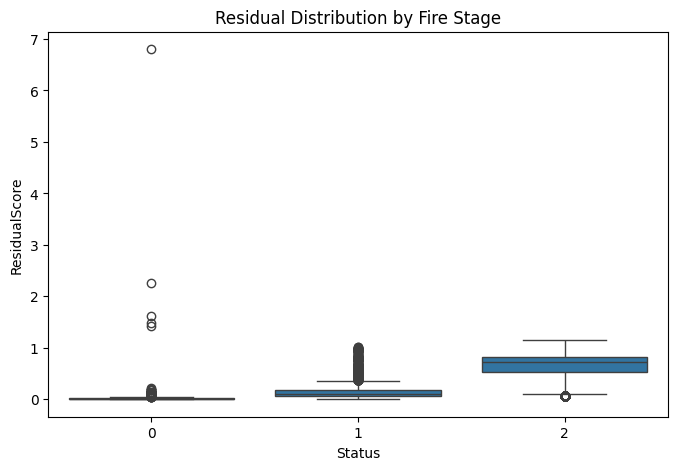

In [29]:
!pip install seaborn
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="Status", y="ResidualScore", data=df_result)
plt.title("Residual Distribution by Fire Stage")
plt.show()

In [30]:
df_result["ResidualScore"] = df_result["ResidualScore"].clip(upper=2)

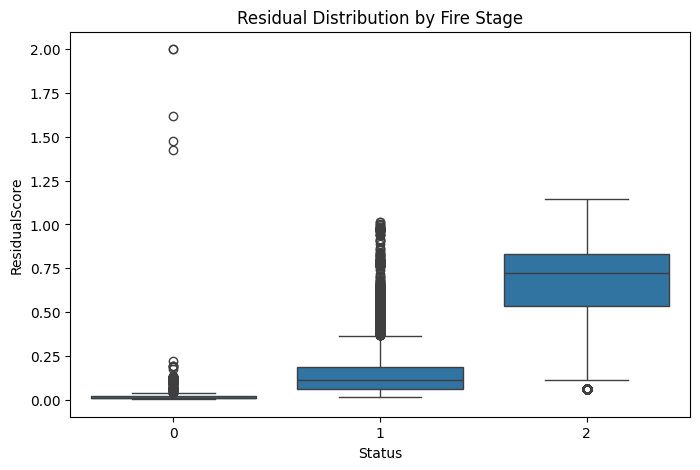

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Status", y="ResidualScore", data=df_result)
plt.title("Residual Distribution by Fire Stage")
plt.show()

In [32]:
df_result.groupby("Status")["ResidualScore"].mean()

Status
0    0.028357
1    0.173544
2    0.611974
Name: ResidualScore, dtype: float32

In [33]:
df_result.groupby("Status")["ResidualScore"].median()

Status
0    0.011938
1    0.109288
2    0.725187
Name: ResidualScore, dtype: float32

In [34]:
risk = (full_residual_score - full_residual_score.min()) / \
       (full_residual_score.max() - full_residual_score.min())

In [35]:
df_result["Risk"] = risk

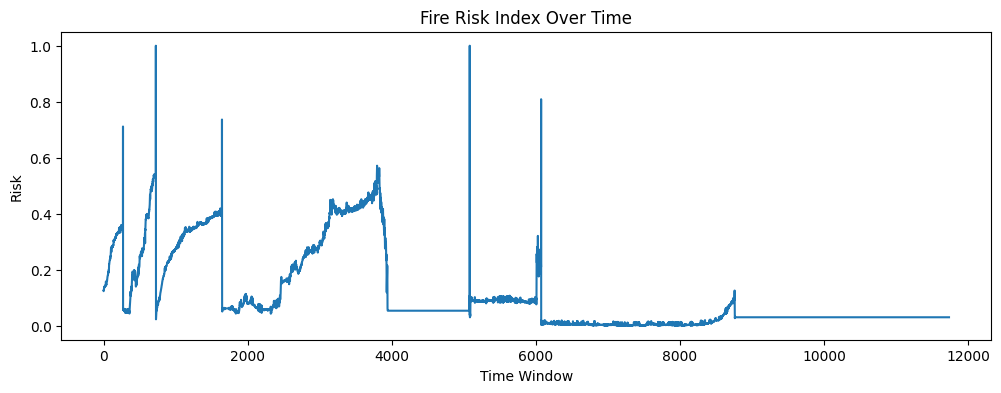

In [36]:
plt.figure(figsize=(12,4))
plt.plot(risk)
plt.title("Fire Risk Index Over Time")
plt.xlabel("Time Window")
plt.ylabel("Risk")
plt.show()

In [37]:
df_result.groupby("Status")["ResidualScore"].mean()

Status
0    0.028357
1    0.173544
2    0.611974
Name: ResidualScore, dtype: float32

In [38]:
df_result.groupby("Status")["ResidualScore"].median()

Status
0    0.011938
1    0.109288
2    0.725187
Name: ResidualScore, dtype: float32

In [39]:
alarm_start = np.where(status_full == 2)[0][0]
print("Alarm starts at:", alarm_start)

Alarm starts at: 171


In [40]:
threshold = 0.25

risk_before_alarm = np.where((risk > threshold) & (np.arange(len(risk)) < alarm_start))[0]

if len(risk_before_alarm) > 0:
    risk_start = risk_before_alarm[-1]  
    early_warning = alarm_start - risk_start
    print("Early warning windows:", early_warning)
else:
    print("No early risk detected before alarm")

Early warning windows: 1


In [41]:
risk_start = np.where(risk > threshold)[0][0]
alarm_start = np.where(status_full == 2)[0][0]

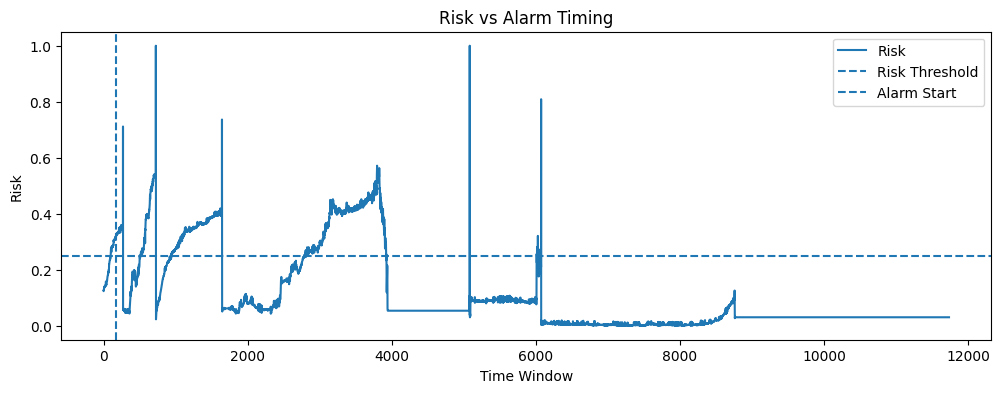

In [42]:
plt.figure(figsize=(12,4))

plt.plot(risk, label="Risk")
plt.axhline(threshold, linestyle="--", label="Risk Threshold")
plt.axvline(alarm_start, linestyle="--", label="Alarm Start")

plt.legend()
plt.title("Risk vs Alarm Timing")
plt.xlabel("Time Window")
plt.ylabel("Risk")
plt.show()

In [43]:
import pickle
import os

os.makedirs("models/dataset1", exist_ok=True)

with open("models/dataset1/scaler_dataset1.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully.")

Scaler saved successfully.


In [44]:
import pandas as pd
import numpy as np


residual_feature_names = ["Temperature", "Humidity", "TVOC", "eCO2", "MQ139"]

X_residual_features_all = pd.DataFrame(full_residuals, columns=[
    f"{c}_residual" for c in residual_feature_names
])

X_residual_features_all["residual_mean"] = full_residuals.mean(axis=1)
X_residual_features_all["residual_max"] = full_residuals.max(axis=1)
X_residual_features_all["residual_std"] = full_residuals.std(axis=1)

In [45]:
threshold = np.percentile(full_residual_score, 30)

normal_idx = full_residual_score < threshold

X_residual_features_normal = X_residual_features_all[normal_idx]

print("All residual features:", X_residual_features_all.shape)
print("Normal residual features:", X_residual_features_normal.shape)

All residual features: (11737, 8)
Normal residual features: (2515, 8)


In [46]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso.fit(X_residual_features_normal)

iso_score = -iso.decision_function(X_residual_features_all)
iso_score = (iso_score - iso_score.min()) / (iso_score.max() - iso_score.min() + 1e-8)

print("Isolation Forest score shape:", iso_score.shape)

Isolation Forest score shape: (11737,)


In [47]:
df_result["ISOScore"] = iso_score
print(df_result.head())

   ResidualScore  Status      Risk  ISOScore
0       0.251888       1  0.124977       1.0
1       0.248793       1  0.123428       1.0
2       0.255507       1  0.126789       1.0
3       0.256115       1  0.127093       1.0
4       0.259275       1  0.128675       1.0


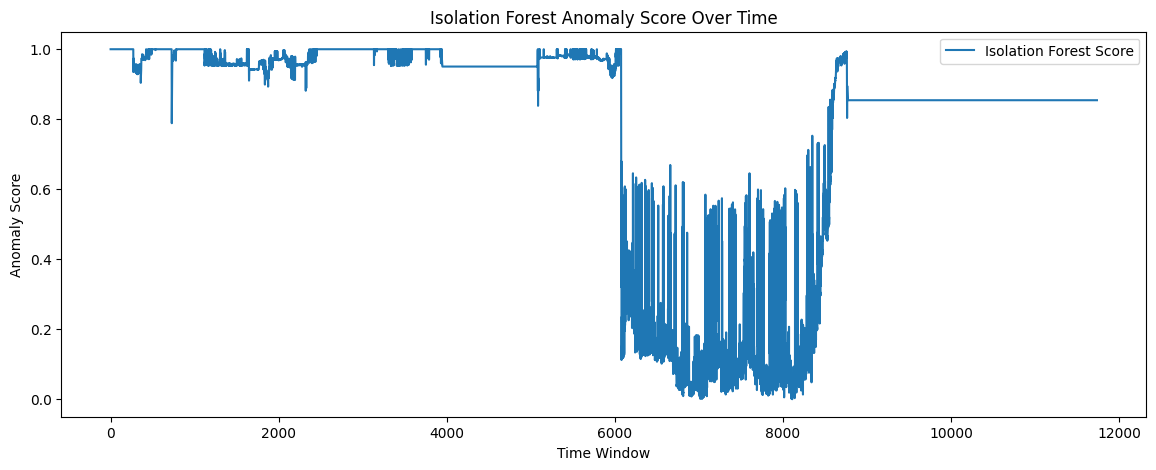

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(iso_score, label="Isolation Forest Score")
plt.title("Isolation Forest Anomaly Score Over Time")
plt.xlabel("Time Window")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [49]:
print(np.unique(status_full, return_counts=True))

(array([0, 1, 2]), array([2780, 6656, 2301]))


Threshold: 0.015009478
Selected normal windows: 1761
Total windows: 11737
Class mix inside selected normal windows:
(array([0]), array([1761]))


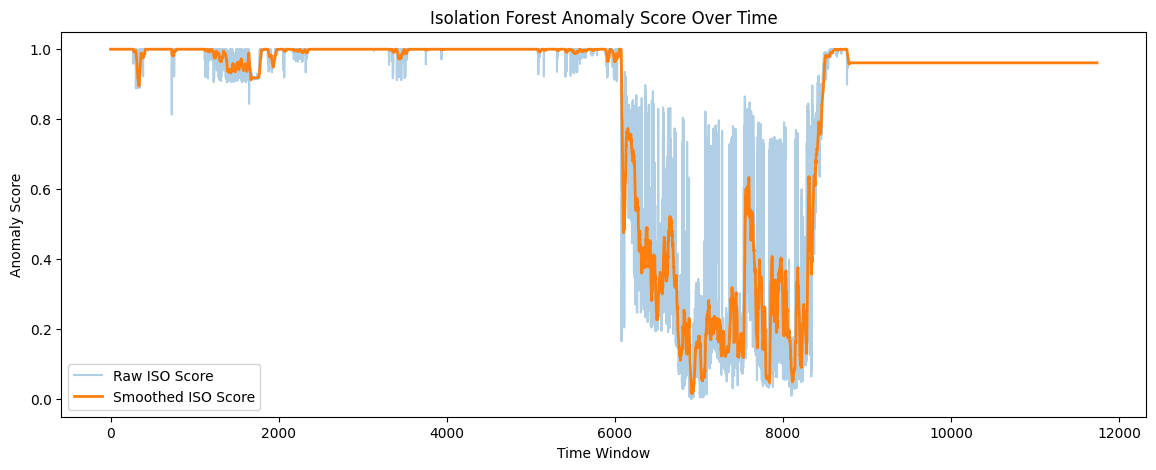

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


residual_feature_names = ["Temperature", "Humidity", "TVOC", "eCO2", "MQ139"]

X_residual_features_all = pd.DataFrame(
    full_residuals,
    columns=[f"{c}_residual" for c in residual_feature_names]
)

X_residual_features_all["residual_mean"] = full_residuals.mean(axis=1)
X_residual_features_all["residual_max"] = full_residuals.max(axis=1)
X_residual_features_all["residual_std"] = full_residuals.std(axis=1)
X_residual_features_all["residual_min"] = full_residuals.min(axis=1)
X_residual_features_all["residual_range"] = (
    X_residual_features_all["residual_max"] - X_residual_features_all["residual_min"]
)


threshold = np.percentile(full_residual_score, 15)
normal_idx = full_residual_score < threshold

print("Threshold:", threshold)
print("Selected normal windows:", normal_idx.sum())
print("Total windows:", len(normal_idx))
print("Class mix inside selected normal windows:")
print(np.unique(status_full[normal_idx], return_counts=True))


scaler_iso = StandardScaler()
X_residual_features_all_scaled = scaler_iso.fit_transform(X_residual_features_all)
X_residual_features_normal_scaled = X_residual_features_all_scaled[normal_idx]


iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42
)

iso.fit(X_residual_features_normal_scaled)


iso_raw = -iso.score_samples(X_residual_features_all_scaled)
iso_score = (iso_raw - iso_raw.min()) / (iso_raw.max() - iso_raw.min() + 1e-8)


iso_score_smooth = pd.Series(iso_score).rolling(25, min_periods=1).mean()


df_result["ISOScore"] = iso_score
df_result["ISOScoreSmooth"] = iso_score_smooth


plt.figure(figsize=(14, 5))
plt.plot(iso_score, alpha=0.35, label="Raw ISO Score")
plt.plot(iso_score_smooth, linewidth=2, label="Smoothed ISO Score")
plt.title("Isolation Forest Anomaly Score Over Time")
plt.xlabel("Time Window")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [51]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42
)

iso.fit(X_residual_features_normal_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [52]:
iso_raw = -iso.score_samples(X_residual_features_all_scaled)

iso_score = (iso_raw - iso_raw.min()) / (iso_raw.max() - iso_raw.min() + 1e-8)

In [53]:
iso_score_smooth = pd.Series(iso_score).rolling(25, min_periods=1).mean()

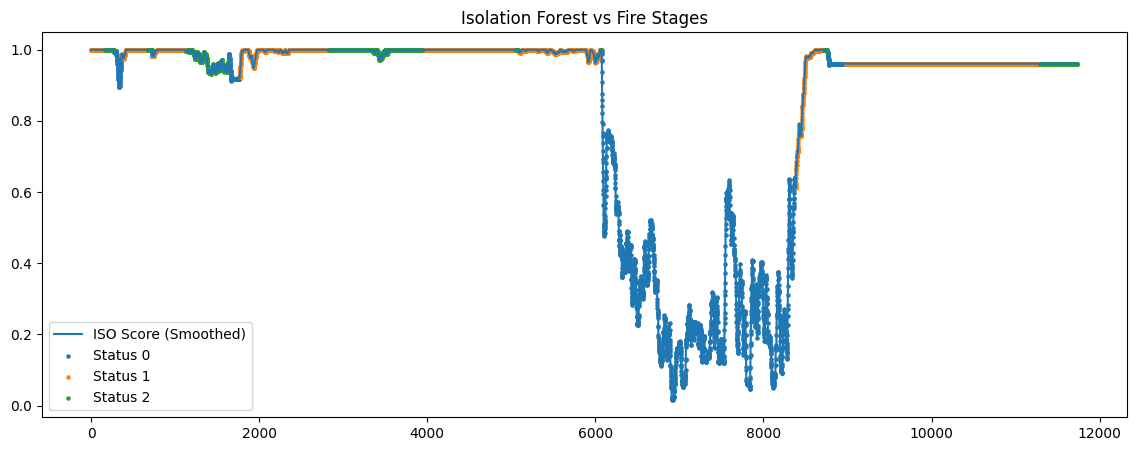

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(iso_score_smooth, label="ISO Score (Smoothed)")

for s in np.unique(status_full):
    idx = np.where(status_full == s)[0]
    plt.scatter(idx, iso_score_smooth[idx], s=5, label=f"Status {s}")

plt.legend()
plt.title("Isolation Forest vs Fire Stages")
plt.show()

In [55]:
print("Std of last 200 residual windows per sensor:")
print(np.std(full_residuals[-200:], axis=0))

print("\nLast 10 residual rows:")
print(full_residuals[-10:])

Std of last 200 residual windows per sensor:
[4.6691131e-08 4.8428774e-08 9.6857548e-08 7.9592290e-08 1.3998370e-07]

Last 10 residual rows:
[[0.02332932 0.02731043 0.1115247  0.07247436 0.07801545]
 [0.02332923 0.02731043 0.1115247  0.07247448 0.07801557]
 [0.02332932 0.02731043 0.1115247  0.07247436 0.07801545]
 [0.02332923 0.02731043 0.1115247  0.07247448 0.07801557]
 [0.02332932 0.02731043 0.1115247  0.07247436 0.07801545]
 [0.02332923 0.02731043 0.1115247  0.07247448 0.07801557]
 [0.02332932 0.02731043 0.1115247  0.07247436 0.07801545]
 [0.02332923 0.02731043 0.1115247  0.07247448 0.07801557]
 [0.02332932 0.02731043 0.1115247  0.07247436 0.07801545]
 [0.02332932 0.02731043 0.1115247  0.07247436 0.07801557]]


In [56]:
summary_iso = df_result.groupby("Status")["ISOScore"].agg(["mean", "median", "std", "min", "max"])
print(summary_iso)

            mean   median       std       min  max
Status                                            
0       0.413674  0.27759  0.328264  0.000000  1.0
1       0.981460  1.00000  0.033284  0.488040  1.0
2       0.984250  1.00000  0.024325  0.898864  1.0


C:\Users\Yasitha\AppData\Local\Temp\ipykernel_25892\2207483527.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Status 0", "Status 1", "Status 2"])


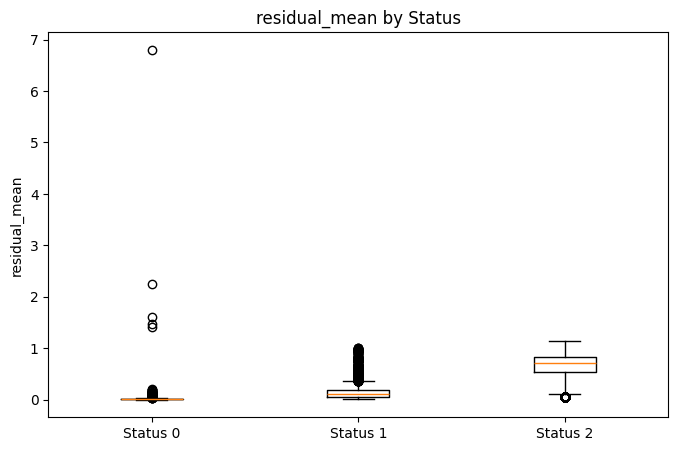

C:\Users\Yasitha\AppData\Local\Temp\ipykernel_25892\2207483527.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Status 0", "Status 1", "Status 2"])


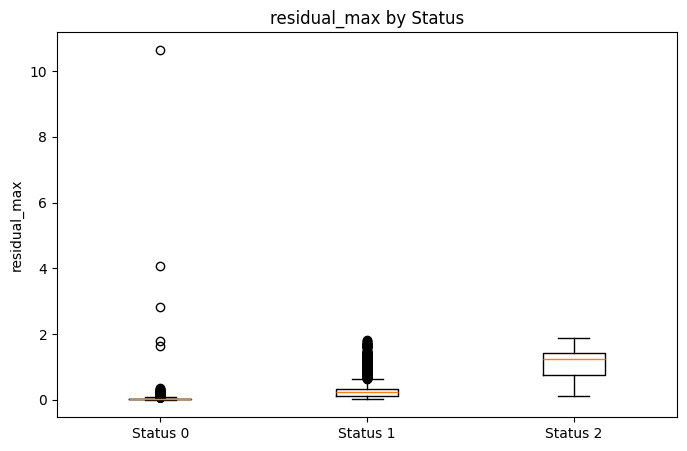

C:\Users\Yasitha\AppData\Local\Temp\ipykernel_25892\2207483527.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Status 0", "Status 1", "Status 2"])


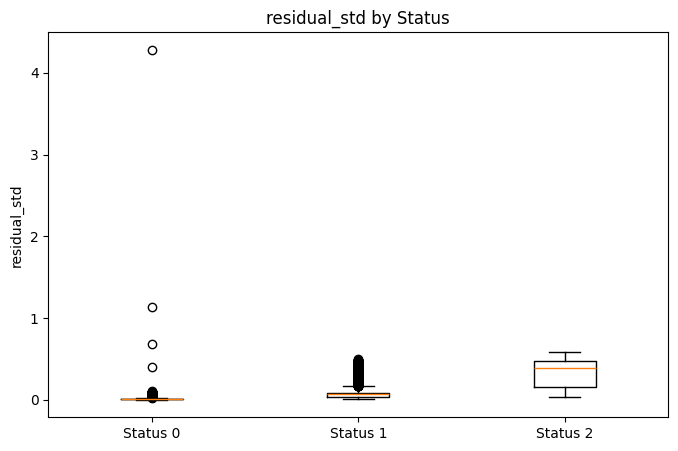

In [57]:
feature_cols = X_residual_features_all.columns.tolist()

for col in ["residual_mean", "residual_max", "residual_std"]:
    plt.figure(figsize=(8, 5))
    data = [
        X_residual_features_all.loc[status_full == 0, col],
        X_residual_features_all.loc[status_full == 1, col],
        X_residual_features_all.loc[status_full == 2, col],
    ]
    plt.boxplot(data, labels=["Status 0", "Status 1", "Status 2"])
    plt.title(f"{col} by Status")
    plt.ylabel(col)
    plt.show()

In [58]:
for c in [0.01, 0.03, 0.05, 0.08, 0.1]:
    iso = IsolationForest(
        n_estimators=300,
        contamination=c,
        random_state=42
    )
    iso.fit(X_residual_features_normal_scaled)

    iso_raw = iso.score_samples(X_residual_features_all_scaled)
    iso_score = (iso_raw.max() - iso_raw) / (iso_raw.max() - iso_raw.min() + 1e-8)

    df_temp = df_result.copy()
    df_temp["ISOScoreTest"] = iso_score

    print(f"\nContamination = {c}")
    print(df_temp.groupby("Status")["ISOScoreTest"].mean())


Contamination = 0.01
Status
0    0.413674
1    0.981460
2    0.984250
Name: ISOScoreTest, dtype: float64

Contamination = 0.03
Status
0    0.413674
1    0.981460
2    0.984250
Name: ISOScoreTest, dtype: float64

Contamination = 0.05
Status
0    0.413674
1    0.981460
2    0.984250
Name: ISOScoreTest, dtype: float64

Contamination = 0.08
Status
0    0.413674
1    0.981460
2    0.984250
Name: ISOScoreTest, dtype: float64

Contamination = 0.1
Status
0    0.413674
1    0.981460
2    0.984250
Name: ISOScoreTest, dtype: float64


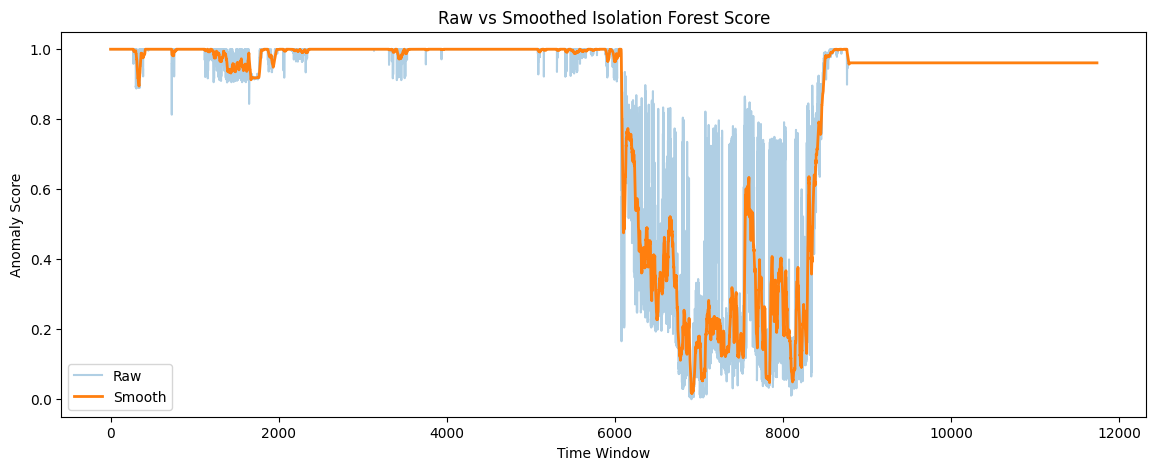

In [59]:
plt.figure(figsize=(14, 5))
plt.plot(df_result["ISOScore"].values, alpha=0.35, label="Raw")
plt.plot(df_result["ISOScoreSmooth"].values, linewidth=2, label="Smooth")
plt.title("Raw vs Smoothed Isolation Forest Score")
plt.xlabel("Time Window")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [60]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


X_train_ae = torch.tensor(X_residual_features_all_scaled[normal_idx], dtype=torch.float32)
X_all_ae = torch.tensor(X_residual_features_all_scaled, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_ae, X_train_ae),
    batch_size=32,
    shuffle=True
)

class ResidualAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

ae = ResidualAutoencoder(input_dim=X_train_ae.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

epochs = 50
train_losses_ae = []

for epoch in range(epochs):
    ae.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        recon = ae(xb)
        loss = criterion(recon, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses_ae.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - AE Loss: {avg_loss:.6f}")

Epoch 1/50 - AE Loss: 0.326766
Epoch 2/50 - AE Loss: 0.008364
Epoch 3/50 - AE Loss: 0.000324
Epoch 4/50 - AE Loss: 0.000299
Epoch 5/50 - AE Loss: 0.000299
Epoch 6/50 - AE Loss: 0.000299
Epoch 7/50 - AE Loss: 0.000311
Epoch 8/50 - AE Loss: 0.000301
Epoch 9/50 - AE Loss: 0.000299
Epoch 10/50 - AE Loss: 0.000297
Epoch 11/50 - AE Loss: 0.000299
Epoch 12/50 - AE Loss: 0.000296
Epoch 13/50 - AE Loss: 0.000299
Epoch 14/50 - AE Loss: 0.000298
Epoch 15/50 - AE Loss: 0.000297
Epoch 16/50 - AE Loss: 0.000295
Epoch 17/50 - AE Loss: 0.000297
Epoch 18/50 - AE Loss: 0.000296
Epoch 19/50 - AE Loss: 0.000296
Epoch 20/50 - AE Loss: 0.000295
Epoch 21/50 - AE Loss: 0.000302
Epoch 22/50 - AE Loss: 0.000297
Epoch 23/50 - AE Loss: 0.000298
Epoch 24/50 - AE Loss: 0.000295
Epoch 25/50 - AE Loss: 0.000290
Epoch 26/50 - AE Loss: 0.000299
Epoch 27/50 - AE Loss: 0.000299
Epoch 28/50 - AE Loss: 0.000295
Epoch 29/50 - AE Loss: 0.000296
Epoch 30/50 - AE Loss: 0.000291
Epoch 31/50 - AE Loss: 0.000286
Epoch 32/50 - AE 

In [61]:
ae.eval()
with torch.no_grad():
    recon_all = ae(X_all_ae)
    ae_error = torch.mean((X_all_ae - recon_all) ** 2, dim=1).cpu().numpy()

ae_score = (ae_error - ae_error.min()) / (ae_error.max() - ae_error.min() + 1e-8)

df_result["AEScore"] = ae_score
print(df_result[["ResidualScore", "ISOScore", "AEScore"]].head())

   ResidualScore  ISOScore   AEScore
0       0.251888       1.0  0.000320
1       0.248793       1.0  0.000332
2       0.255507       1.0  0.000320
3       0.256115       1.0  0.000334
4       0.259275       1.0  0.000331


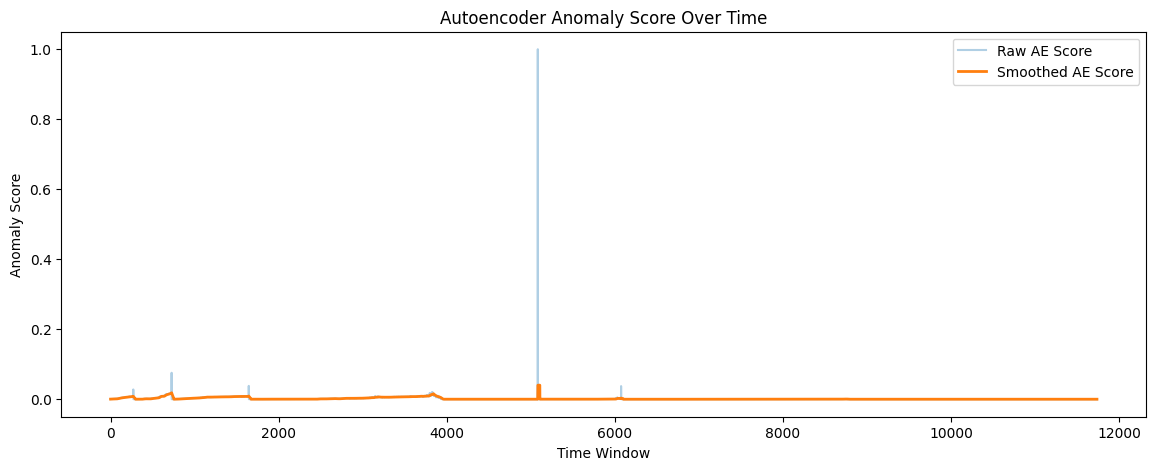

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

ae_score_smooth = pd.Series(ae_score).rolling(25, min_periods=1).mean()
df_result["AEScoreSmooth"] = ae_score_smooth

plt.figure(figsize=(14, 5))
plt.plot(ae_score, alpha=0.35, label="Raw AE Score")
plt.plot(ae_score_smooth, linewidth=2, label="Smoothed AE Score")
plt.title("Autoencoder Anomaly Score Over Time")
plt.xlabel("Time Window")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [63]:
print(df_result.groupby("Status")["AEScore"].agg(["mean", "median", "std", "min", "max"]))

            mean        median       std           min       max
Status                                                          
0       0.000436  4.678959e-07  0.019053  0.000000e+00  1.000000
1       0.000573  6.808470e-05  0.001536  4.403359e-07  0.014876
2       0.005235  6.130757e-03  0.003687  1.902167e-05  0.020399


C:\Users\Yasitha\AppData\Local\Temp\ipykernel_25892\289052757.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Status 0", "Status 1", "Status 2"])


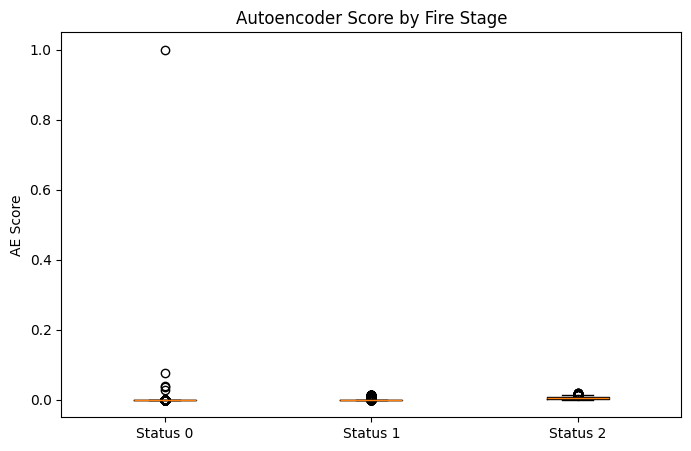

In [64]:
plt.figure(figsize=(8, 5))
data = [
    df_result[df_result["Status"] == 0]["AEScore"],
    df_result[df_result["Status"] == 1]["AEScore"],
    df_result[df_result["Status"] == 2]["AEScore"]
]
plt.boxplot(data, labels=["Status 0", "Status 1", "Status 2"])
plt.title("Autoencoder Score by Fire Stage")
plt.ylabel("AE Score")
plt.show()

In [65]:
import pandas as pd

fusion_df = pd.DataFrame({
    "residual": full_residual_score,
    "risk_tcn": risk,
    "iso_score": iso_score,
    "ae_score": ae_score,
    "label": status_full
})

print(fusion_df.head())

   residual  risk_tcn  iso_score  ae_score  label
0  0.251888  0.124977        1.0  0.000320      1
1  0.248793  0.123428        1.0  0.000332      1
2  0.255507  0.126789        1.0  0.000320      1
3  0.256115  0.127093        1.0  0.000334      1
4  0.259275  0.128675        1.0  0.000331      1


In [66]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

X = fusion_df.drop("label", axis=1)
y = fusion_df["label"]

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X, y)

y_pred = xgb.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94      2780
           1       0.89      0.99      0.93      6656
           2       0.97      0.76      0.85      2301

    accuracy                           0.92     11737
   macro avg       0.95      0.88      0.91     11737
weighted avg       0.93      0.92      0.92     11737



In [67]:
probs = xgb.predict_proba(X)

risk_final = (
    0.1 * probs[:, 0] +
    0.5 * probs[:, 1] +
    1.0 * probs[:, 2]
)

df_result["FinalRisk"] = risk_final

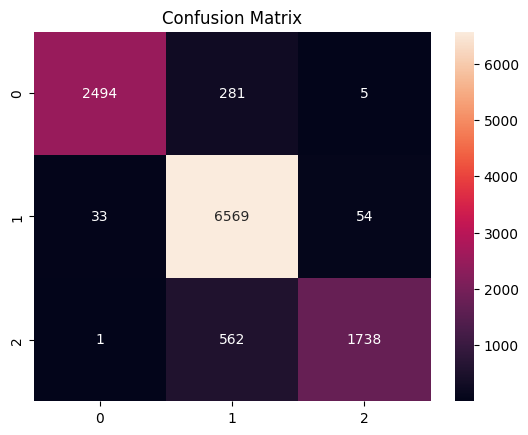

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

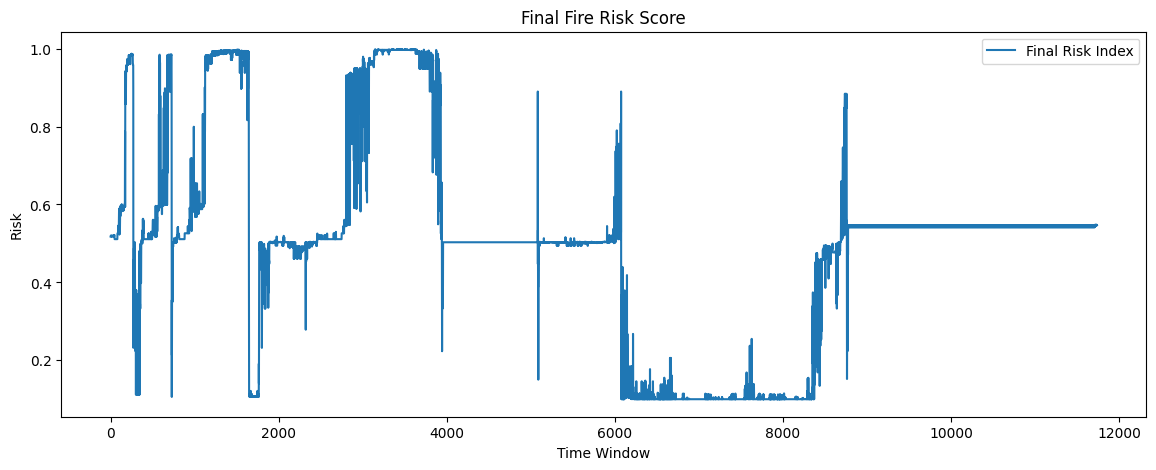

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(risk_final, label="Final Risk Index")
plt.title("Final Fire Risk Score")
plt.xlabel("Time Window")
plt.ylabel("Risk")
plt.legend()
plt.show()

In [70]:
import numpy as np

def persistence_filter(risk, threshold=0.6, min_len=5):
    out = np.zeros(len(risk), dtype=int)
    count = 0

    for i, r in enumerate(risk):
        if r >= threshold:
            count += 1
        else:
            count = 0

        if count >= min_len:
            out[i] = 1

    return out

persist_flag = persistence_filter(risk_final, threshold=0.6, min_len=5)
df_result["PersistFlag"] = persist_flag

In [71]:
final_stage = np.zeros(len(risk_final), dtype=int)

final_stage_3 = np.zeros(len(risk_final), dtype=int)
final_stage_3[risk_final >= 0.35] = 1
final_stage_3[(risk_final >= 0.60) & (persist_flag == 1)] = 2
final_stage_3[risk_final >= 0.85] = 3

df_result["PredictedStage"] = final_stage

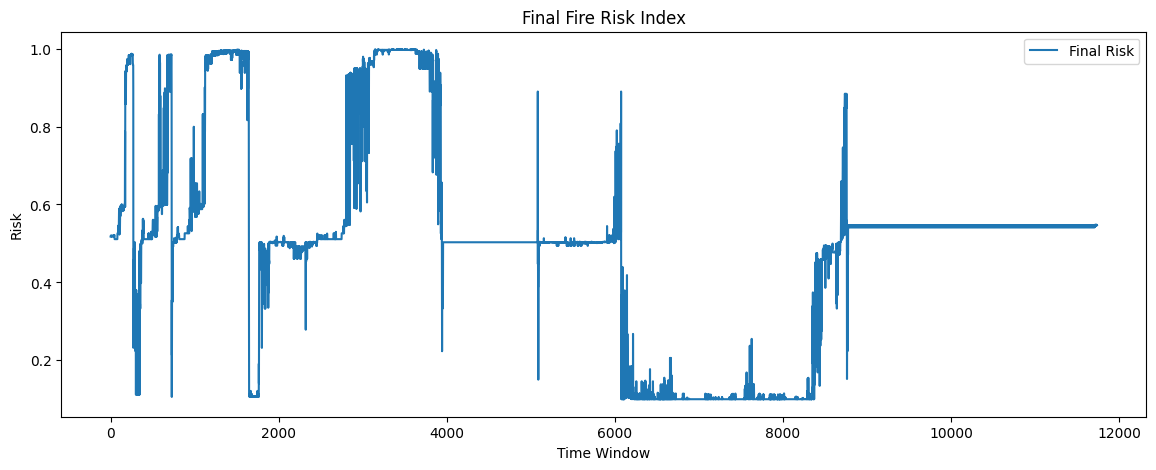

In [72]:
plt.figure(figsize=(14, 5))
plt.plot(risk_final, label="Final Risk")
plt.title("Final Fire Risk Index")
plt.xlabel("Time Window")
plt.ylabel("Risk")
plt.legend()
plt.show()

In [73]:
df_result.to_csv("results/dataset1_full_pipeline.csv", index=False)

In [74]:
checks = {
    "full_residuals": "full_residuals" in globals(),
    "full_residual_score": "full_residual_score" in globals(),
    "risk": "risk" in globals(),
    "iso_score": "iso_score" in globals(),
    "ae_score": "ae_score" in globals(),
    "fusion_df": "fusion_df" in globals(),
    "xgb": "xgb" in globals(),
    "risk_final": "risk_final" in globals(),
    "persist_flag": "persist_flag" in globals(),
}

print(checks)

if "df_result" in globals():
    print("\ndf_result columns:")
    print(df_result.columns.tolist())

{'full_residuals': True, 'full_residual_score': True, 'risk': True, 'iso_score': True, 'ae_score': True, 'fusion_df': True, 'xgb': True, 'risk_final': True, 'persist_flag': True}

df_result columns:
['ResidualScore', 'Status', 'Risk', 'ISOScore', 'ISOScoreSmooth', 'AEScore', 'AEScoreSmooth', 'FinalRisk', 'PersistFlag', 'PredictedStage']


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


X = fusion_df.drop("label", axis=1)
y = fusion_df["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)


xgb_eval = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_eval.fit(X_train, y_train)


y_test_pred = xgb_eval.predict(X_test)
test_probs = xgb_eval.predict_proba(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Train shape: (9389, 4) (9389,)
Test shape : (2348, 4) (2348,)
Test Accuracy: 0.9165247018739353

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       556
           1       0.88      0.99      0.93      1332
           2       0.97      0.76      0.85       460

    accuracy                           0.92      2348
   macro avg       0.95      0.87      0.90      2348
weighted avg       0.92      0.92      0.91      2348



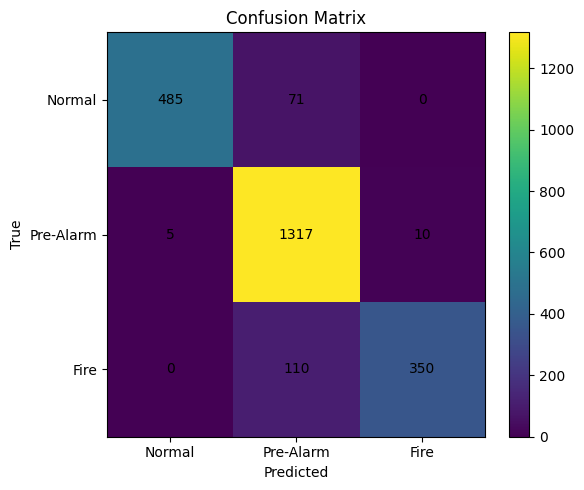

In [76]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.xticks([0, 1, 2], ["Normal", "Pre-Alarm", "Fire"])
plt.yticks([0, 1, 2], ["Normal", "Pre-Alarm", "Fire"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [77]:
test_risk_final = (
    0.1 * test_probs[:, 0] +
    0.5 * test_probs[:, 1] +
    1.0 * test_probs[:, 2]
)

df_test_result = X_test.copy()
df_test_result["TrueLabel"] = y_test.values
df_test_result["PredLabel"] = y_test_pred
df_test_result["FinalRisk"] = test_risk_final

print(df_test_result.head())

       residual  risk_tcn  iso_score      ae_score  TrueLabel  PredLabel  \
2784   0.502337  0.250340   1.000000  2.785682e-03          1          1   
11265  0.062531  0.030194   0.961005  1.902167e-05          1          1   
8836   0.062531  0.030194   0.961005  1.902170e-05          0          1   
8066   0.008321  0.003058   0.349613  4.864569e-07          0          0   
4331   0.109288  0.053598   1.000000  6.808470e-05          1          1   

       FinalRisk  
2784    0.536629  
11265   0.550500  
8836    0.548106  
8066    0.100273  
4331    0.501800  


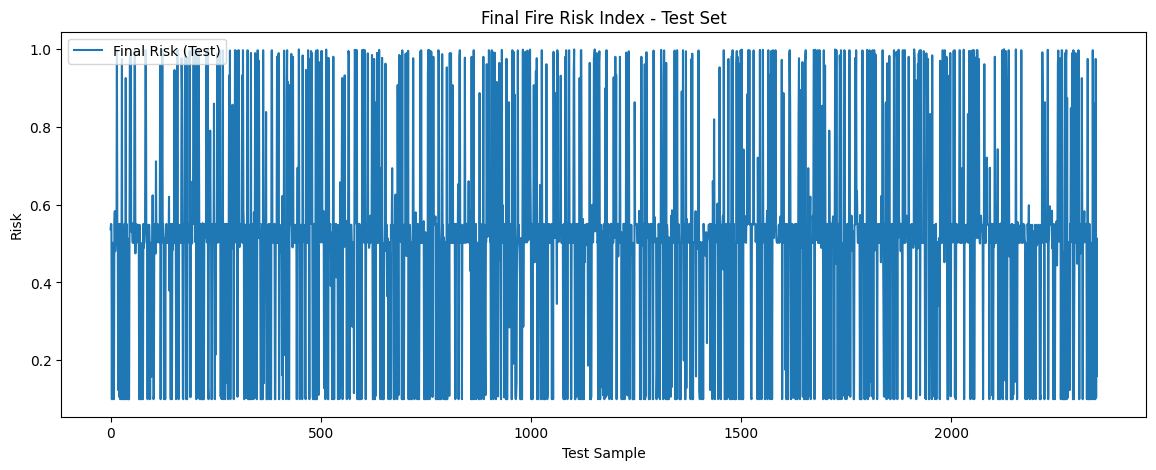

In [78]:
plt.figure(figsize=(14, 5))
plt.plot(df_test_result["FinalRisk"].values, label="Final Risk (Test)")
plt.title("Final Fire Risk Index - Test Set")
plt.xlabel("Test Sample")
plt.ylabel("Risk")
plt.legend()
plt.show()

iso_score    0.743621
residual     0.195764
ae_score     0.060615
risk_tcn     0.000000
dtype: float32


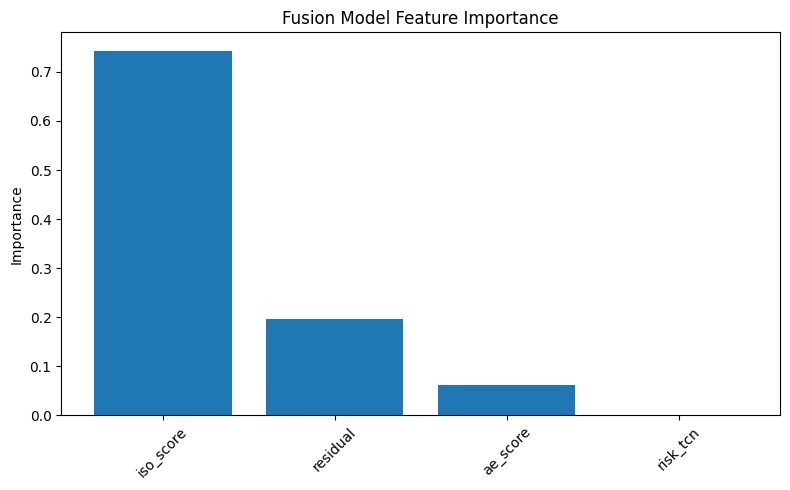

In [79]:
importance = pd.Series(xgb_eval.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

plt.figure(figsize=(8, 5))
plt.bar(importance.index, importance.values)
plt.title("Fusion Model Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

import os

os.makedirs("results", exist_ok=True)
os.makedirs("models/dataset1", exist_ok=True)

df_test_result.to_csv("results/dataset1_test_results.csv", index=False)
xgb_eval.save_model("models/dataset1/xgb_dataset1.json")

In [80]:
import os

os.makedirs("results", exist_ok=True)


report = classification_report(y_test, y_test_pred)

with open("results/dataset1_classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved")

Classification report saved


In [81]:
cm = confusion_matrix(y_test, y_test_pred)

import pandas as pd

cm_df = pd.DataFrame(cm, 
                     index=["True_0", "True_1", "True_2"], 
                     columns=["Pred_0", "Pred_1", "Pred_2"])

cm_df.to_csv("results/dataset1_confusion_matrix.csv")

print("Confusion matrix saved")

Confusion matrix saved


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sensor_cols = ["Temperature", "Humidity", "TVOC", "eCO2", "MQ139"]

def compute_drift_features(df, sensor_cols, short_window=20, long_window=200):
    drift_df = pd.DataFrame(index=df.index)

    for col in sensor_cols:
        short_ma = df[col].rolling(short_window, min_periods=1).mean()
        long_ma = df[col].rolling(long_window, min_periods=1).mean()

        drift_df[f"{col}_short_ma"] = short_ma
        drift_df[f"{col}_long_ma"] = long_ma
        drift_df[f"{col}_drift"] = (short_ma - long_ma).abs()

    drift_cols = [f"{col}_drift" for col in sensor_cols]
    drift_df["drift_strength"] = drift_df[drift_cols].mean(axis=1)

    return drift_df

drift_df = compute_drift_features(df_model, sensor_cols)

print(drift_df.head())

   Temperature_short_ma  Temperature_long_ma  Temperature_drift  \
0             21.300000            21.300000                0.0   
1             21.300000            21.300000                0.0   
2             21.333333            21.333333                0.0   
3             21.350000            21.350000                0.0   
4             21.360000            21.360000                0.0   

   Humidity_short_ma  Humidity_long_ma  Humidity_drift  TVOC_short_ma  \
0          43.500000         43.500000             0.0            0.0   
1          43.500000         43.500000             0.0            0.0   
2          43.533333         43.533333             0.0            0.0   
3          43.550000         43.550000             0.0            0.0   
4          43.580000         43.580000             0.0            0.0   

   TVOC_long_ma  TVOC_drift  eCO2_short_ma  eCO2_long_ma  eCO2_drift  \
0           0.0         0.0          400.0         400.0         0.0   
1           0.

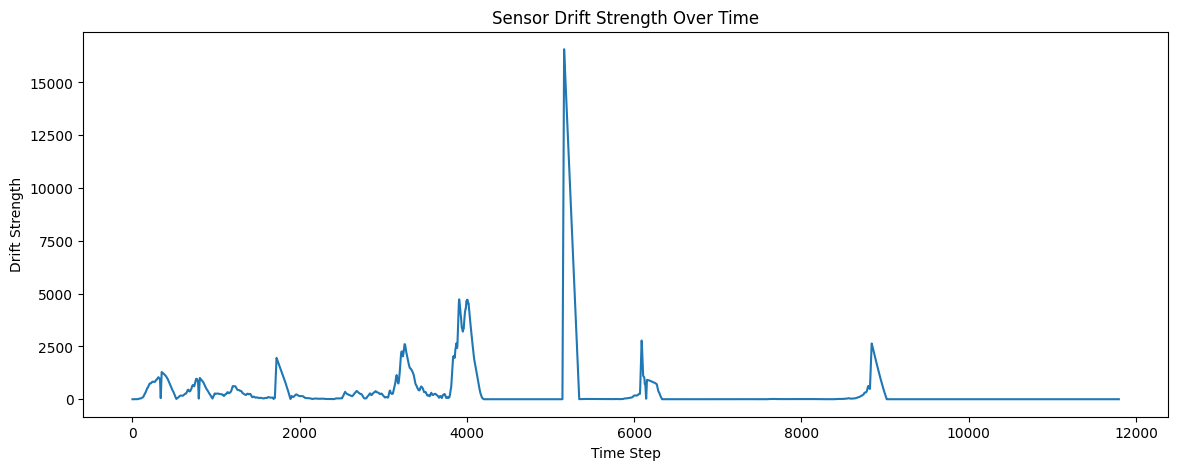

In [83]:
plt.figure(figsize=(14, 5))
plt.plot(drift_df["drift_strength"].values)
plt.title("Sensor Drift Strength Over Time")
plt.xlabel("Time Step")
plt.ylabel("Drift Strength")
plt.show()

In [84]:
def rolling_window_mean(arr, window_size):
    vals = []
    for i in range(len(arr) - window_size + 1):
        vals.append(arr[i:i+window_size].mean())
    return np.array(vals)

window_drift_strength = rolling_window_mean(
    drift_df["drift_strength"].values,
    window_size
)

print(window_drift_strength.shape)
print(len(full_residual_score))

(11738,)
11737


In [85]:
min_len = min(len(window_drift_strength), len(full_residual_score), len(fusion_df))

window_drift_strength = window_drift_strength[:min_len]

In [86]:
drift_threshold = np.percentile(window_drift_strength, 95)
drift_flag = (window_drift_strength > drift_threshold).astype(int)

print("Drift threshold:", drift_threshold)
print(np.unique(drift_flag, return_counts=True))

Drift threshold: 1802.5697659999994
(array([0, 1]), array([11150,   587]))


In [87]:
fusion_df = fusion_df.iloc[:min_len].copy()
fusion_df["drift_strength"] = window_drift_strength
fusion_df["drift_flag"] = drift_flag

print(fusion_df.head())

   residual  risk_tcn  iso_score  ae_score  label  drift_strength  drift_flag
0  0.251888  0.124977        1.0  0.000320      1        0.798002           0
1  0.248793  0.123428        1.0  0.000332      1        0.813025           0
2  0.255507  0.126789        1.0  0.000320      1        0.834129           0
3  0.256115  0.127093        1.0  0.000334      1        0.862829           0
4  0.259275  0.128675        1.0  0.000331      1        0.907538           0


In [88]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = fusion_df.drop("label", axis=1)
y = fusion_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xgb_eval = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_eval.fit(X_train, y_train)

y_test_pred = xgb_eval.predict(X_test)
test_probs = xgb_eval.predict_proba(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.952725724020443
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       556
           1       0.93      0.99      0.96      1332
           2       0.98      0.80      0.88       460

    accuracy                           0.95      2348
   macro avg       0.97      0.92      0.94      2348
weighted avg       0.95      0.95      0.95      2348



In [89]:
test_risk_final = (
    0.1 * test_probs[:, 0] +
    0.5 * test_probs[:, 1] +
    1.0 * test_probs[:, 2]
)

def persistence_filter(risk, threshold=0.6, min_len=5):
    out = np.zeros(len(risk), dtype=int)
    count = 0
    for i, r in enumerate(risk):
        if r >= threshold:
            count += 1
        else:
            count = 0
        if count >= min_len:
            out[i] = 1
    return out

persist_flag = persistence_filter(test_risk_final, threshold=0.6, min_len=5)


test_drift_flag = fusion_df.loc[X_test.index, "drift_flag"].values

final_alarm = ((persist_flag == 1) & (test_drift_flag == 0)).astype(int)

In [90]:

df_test_result = X_test.copy()

df_test_result["TrueLabel"] = y_test.values
df_test_result["PredLabel"] = y_test_pred
df_test_result["FinalRisk"] = test_risk_final
df_test_result["PersistFlag"] = persist_flag
df_test_result["DriftFlag"] = test_drift_flag
df_test_result["FinalAlarm"] = final_alarm

print(df_test_result.head())

       residual  risk_tcn  iso_score      ae_score  drift_strength  \
2784   0.502337  0.250340   1.000000  2.785682e-03      140.763282   
11265  0.062531  0.030194   0.961005  1.902167e-05        0.000000   
8836   0.062531  0.030194   0.961005  1.902170e-05     2221.155825   
8066   0.008321  0.003058   0.349613  4.864569e-07        1.349182   
4331   0.109288  0.053598   1.000000  6.808470e-05        0.000000   

       drift_flag  TrueLabel  PredLabel  FinalRisk  PersistFlag  DriftFlag  \
2784            0          1          1   0.511742            0          0   
11265           0          1          1   0.583546            0          0   
8836            1          0          0   0.104332            0          1   
8066            0          0          0   0.100347            0          0   
4331            0          1          1   0.514036            0          0   

       FinalAlarm  
2784            0  
11265           0  
8836            0  
8066            0  
4331      

In [91]:
print("Final alarm counts:")
print(np.unique(final_alarm, return_counts=True))

Final alarm counts:
(array([0]), array([2348]))


In [92]:
print(pd.crosstab(df_test_result["TrueLabel"], df_test_result["FinalAlarm"],
                  rownames=["TrueLabel"], colnames=["FinalAlarm"]))

FinalAlarm     0
TrueLabel       
0            556
1           1332
2            460


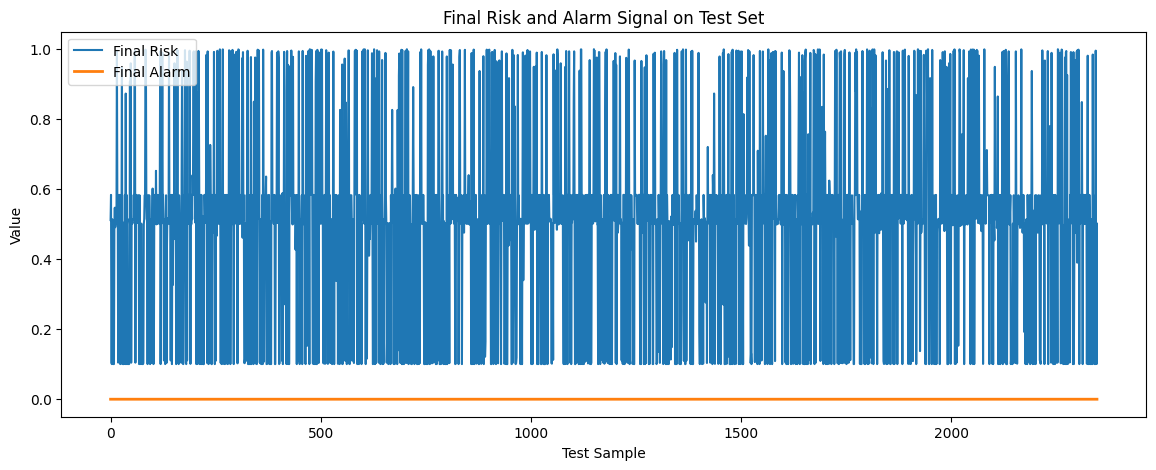

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_test_result["FinalRisk"].values, label="Final Risk")
plt.plot(df_test_result["FinalAlarm"].values, label="Final Alarm", linewidth=2)
plt.title("Final Risk and Alarm Signal on Test Set")
plt.xlabel("Test Sample")
plt.ylabel("Value")
plt.legend()
plt.show()

In [94]:
import os
os.makedirs("results", exist_ok=True)

df_test_result.to_csv("results/dataset1_test_results_with_alarm.csv", index=False)
print("Saved: results/dataset1_test_results_with_alarm.csv")

Saved: results/dataset1_test_results_with_alarm.csv


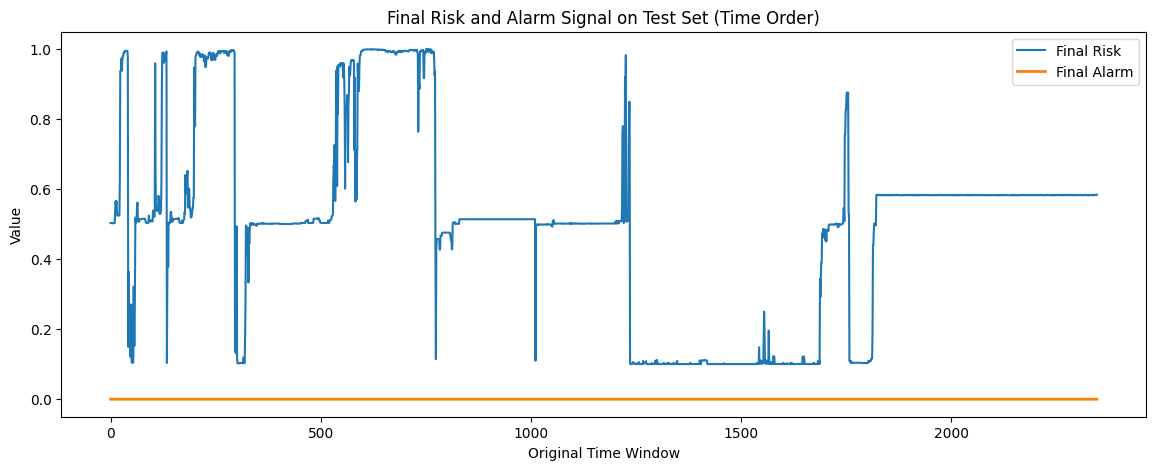

In [95]:
df_test_result = df_test_result.sort_index()

plt.figure(figsize=(14, 5))
plt.plot(df_test_result["FinalRisk"].values, label="Final Risk")
plt.plot(df_test_result["FinalAlarm"].values, label="Final Alarm", linewidth=2)
plt.title("Final Risk and Alarm Signal on Test Set (Time Order)")
plt.xlabel("Original Time Window")
plt.ylabel("Value")
plt.legend()
plt.show()

In [96]:
true_alarm = (df_test_result["TrueLabel"] >= 1).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(true_alarm, df_test_result["FinalAlarm"]))

cm_alarm = confusion_matrix(true_alarm, df_test_result["FinalAlarm"])
print(cm_alarm)

              precision    recall  f1-score   support

           0       0.24      1.00      0.38       556
           1       0.00      0.00      0.00      1792

    accuracy                           0.24      2348
   macro avg       0.12      0.50      0.19      2348
weighted avg       0.06      0.24      0.09      2348

[[ 556    0]
 [1792    0]]


C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [97]:
print(pd.crosstab(df_test_result["TrueLabel"], df_test_result["FinalAlarm"]))
print(classification_report(true_alarm, df_test_result["FinalAlarm"]))

FinalAlarm     0
TrueLabel       
0            556
1           1332
2            460
              precision    recall  f1-score   support

           0       0.24      1.00      0.38       556
           1       0.00      0.00      0.00      1792

    accuracy                           0.24      2348
   macro avg       0.12      0.50      0.19      2348
weighted avg       0.06      0.24      0.09      2348



C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [98]:
print(pd.crosstab(df_test_result["TrueLabel"], df_test_result["FinalAlarm"]))

FinalAlarm     0
TrueLabel       
0            556
1           1332
2            460


In [99]:
true_alarm = (df_test_result["TrueLabel"] >= 1).astype(int)

from sklearn.metrics import classification_report

print(classification_report(true_alarm, df_test_result["FinalAlarm"]))

              precision    recall  f1-score   support

           0       0.24      1.00      0.38       556
           1       0.00      0.00      0.00      1792

    accuracy                           0.24      2348
   macro avg       0.12      0.50      0.19      2348
weighted avg       0.06      0.24      0.09      2348



C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [100]:
final_alarm = persist_flag.copy()

In [101]:
final_alarm = np.zeros(len(test_risk_final), dtype=int)

for i in range(len(test_risk_final)):
    if persist_flag[i] == 1:
        if test_drift_flag[i] == 0:
            final_alarm[i] = 1
        elif test_drift_flag[i] == 1:
           
            if test_risk_final[i] > 0.75:
                final_alarm[i] = 1

In [102]:
true_alarm = (df_test_result["TrueLabel"] >= 1).astype(int)

from sklearn.metrics import classification_report

print(classification_report(true_alarm, df_test_result["FinalAlarm"]))

              precision    recall  f1-score   support

           0       0.24      1.00      0.38       556
           1       0.00      0.00      0.00      1792

    accuracy                           0.24      2348
   macro avg       0.12      0.50      0.19      2348
weighted avg       0.06      0.24      0.09      2348



C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [103]:
print(np.unique(persist_flag, return_counts=True))
print(np.unique(test_drift_flag, return_counts=True))
print(np.min(test_risk_final), np.max(test_risk_final))

(array([0, 1]), array([2347,    1]))
(array([0, 1]), array([2224,  124]))
0.10023838 0.9996091


In [104]:
df_test_result = X_test.copy()
df_test_result["TrueLabel"] = y_test.values
df_test_result["PredLabel"] = y_test_pred
df_test_result["FinalRisk"] = test_risk_final
df_test_result["DriftFlag"] = fusion_df.loc[X_test.index, "drift_flag"].values


df_test_result = df_test_result.sort_index()

In [105]:
import numpy as np

def persistence_filter(risk, threshold=0.5, min_len=3):
    out = np.zeros(len(risk), dtype=int)
    count = 0
    for i, r in enumerate(risk):
        if r >= threshold:
            count += 1
        else:
            count = 0
        if count >= min_len:
            out[i] = 1
    return out

persist_flag = persistence_filter(
    df_test_result["FinalRisk"].values,
    threshold=0.5,
    min_len=3
)

df_test_result["PersistFlag"] = persist_flag

In [106]:
final_alarm = (
    (df_test_result["PersistFlag"].values == 1) &
    (df_test_result["DriftFlag"].values == 0)
).astype(int)

df_test_result["FinalAlarm"] = final_alarm

In [107]:
final_alarm = np.zeros(len(df_test_result), dtype=int)

for i in range(len(df_test_result)):
    if df_test_result["PersistFlag"].iloc[i] == 1:
        if df_test_result["DriftFlag"].iloc[i] == 0:
            final_alarm[i] = 1
        elif df_test_result["FinalRisk"].iloc[i] >= 0.75:
            final_alarm[i] = 1

df_test_result["FinalAlarm"] = final_alarm

In [108]:
import pandas as pd
from sklearn.metrics import classification_report

print(np.unique(df_test_result["PersistFlag"], return_counts=True))
print(pd.crosstab(df_test_result["TrueLabel"], df_test_result["FinalAlarm"]))

true_alarm = (df_test_result["TrueLabel"] >= 1).astype(int)
print(classification_report(true_alarm, df_test_result["FinalAlarm"]))

(array([0, 1]), array([ 735, 1613]))
FinalAlarm    0     1
TrueLabel            
0           556     0
1           178  1154
2             1   459
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       556
           1       1.00      0.90      0.95      1792

    accuracy                           0.92      2348
   macro avg       0.88      0.95      0.90      2348
weighted avg       0.94      0.92      0.93      2348



In [109]:
split_idx = int(len(df_model) * 0.8)

df_train = df_model.iloc[:split_idx]
df_test  = df_model.iloc[split_idx:]

In [110]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [111]:
xgb.predict(X_test)

array([1, 1, 0, ..., 0, 1, 0], shape=(2348,))

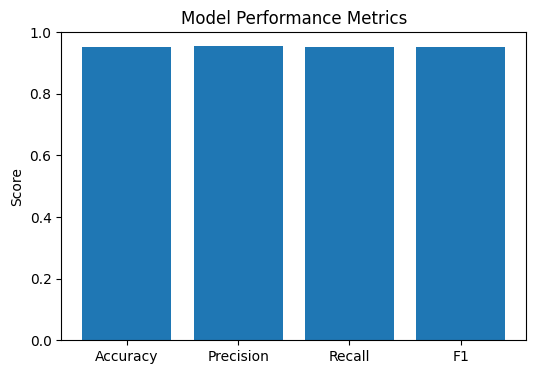

In [112]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, average='weighted')
rec = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [acc, prec, rec, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.ylabel("Score")
plt.show()

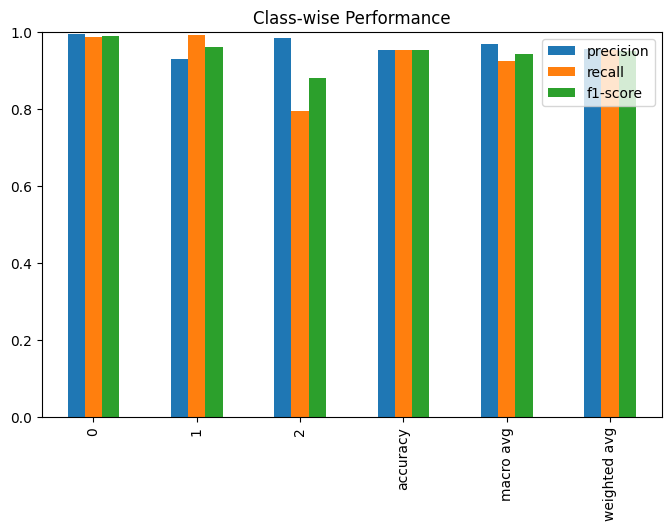

In [113]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_test_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report[["precision","recall","f1-score"]].plot(kind="bar", figsize=(8,5))
plt.title("Class-wise Performance")
plt.ylim(0,1)
plt.show()

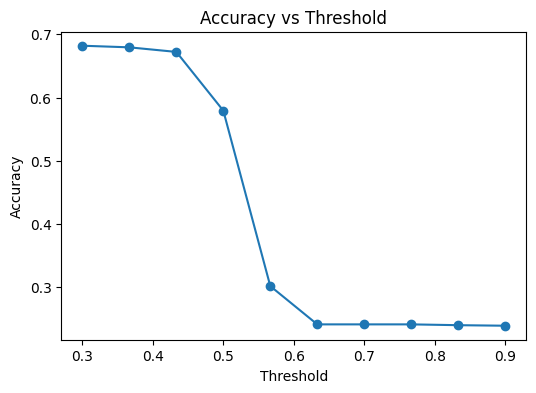

In [114]:
thresholds = np.linspace(0.3, 0.9, 10)
acc_list = []

true_alarm = (y_test >= 1).astype(int)

for t in thresholds:
    persist_flag = persistence_filter(test_risk_final, threshold=t, min_len=3)
    pred_alarm = persist_flag

    acc = accuracy_score(true_alarm, pred_alarm)
    acc_list.append(acc)

plt.figure(figsize=(6,4))
plt.plot(thresholds, acc_list, marker='o')
plt.title("Accuracy vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.show()

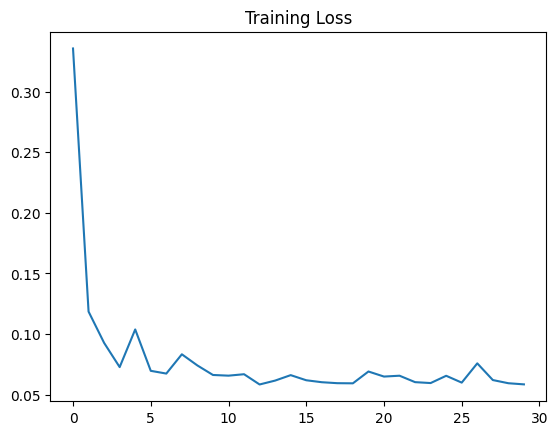

In [115]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

In [116]:

print("Saving AE and ISO models...")
torch.save(ae.state_dict(), "models/dataset1/ae_dataset1.pth")
with open("models/dataset1/iso_dataset1.pkl", "wb") as f:
    pickle.dump(iso, f)

if 'scaler_iso' in globals():
    with open("models/dataset1/scaler_iso1.pkl", "wb") as f:
        pickle.dump(scaler_iso, f)
print("Finished saving all models to models/dataset1/")

Saving AE and ISO models...
Finished saving all models to models/dataset1/


In [ ]:
# ==========================================
# FIXED BASELINE EVALUATION (DATASET 1)
# ==========================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n==============================")
print(" BASELINE MODEL COMPARISON ")
print("==============================\n")

rows = []

# ------------------------------------------
# A. TCN-only baseline on full df_result
# ------------------------------------------
# df_result uses Status: 0 = normal, 1/2 = fire-related
true_label_full = (df_result["Status"] >= 1).astype(int)

# TCN risk already exists as df_result["Risk"]
tcn_pred = (df_result["Risk"].values >= 0.5).astype(int)

tcn_acc = accuracy_score(true_label_full, tcn_pred)
tcn_prec = precision_score(true_label_full, tcn_pred, zero_division=0)
tcn_rec = recall_score(true_label_full, tcn_pred, zero_division=0)
tcn_f1 = f1_score(true_label_full, tcn_pred, zero_division=0)

print("----- TCN ONLY -----")
print("Accuracy :", tcn_acc)
print("Precision:", tcn_prec)
print("Recall   :", tcn_rec)
print("F1 Score :", tcn_f1)
print()

rows.append({
    "Model": "TCN-only",
    "Accuracy": tcn_acc,
    "Precision": tcn_prec,
    "Recall": tcn_rec,
    "F1": tcn_f1
})

# ------------------------------------------
# B. ISO-only baseline on full df_result
# ------------------------------------------
if "ISOScore" in df_result.columns:
    iso_pred = (df_result["ISOScore"].values >= 0.5).astype(int)

    iso_acc = accuracy_score(true_label_full, iso_pred)
    iso_prec = precision_score(true_label_full, iso_pred, zero_division=0)
    iso_rec = recall_score(true_label_full, iso_pred, zero_division=0)
    iso_f1 = f1_score(true_label_full, iso_pred, zero_division=0)

    print("----- ISOLATION FOREST ONLY -----")
    print("Accuracy :", iso_acc)
    print("Precision:", iso_prec)
    print("Recall   :", iso_rec)
    print("F1 Score :", iso_f1)
    print()

    rows.append({
        "Model": "Isolation Forest",
        "Accuracy": iso_acc,
        "Precision": iso_prec,
        "Recall": iso_rec,
        "F1": iso_f1
    })
else:
    print("ISO baseline skipped: ISOScore not found in df_result.\n")

# ------------------------------------------
# C. Hybrid Fusion baseline on df_test_result
# ------------------------------------------
true_alarm_test = (df_test_result["TrueLabel"] >= 1).astype(int)

# If FinalAlarm is missing, rebuild it from existing test columns
if "FinalAlarm" not in df_test_result.columns:
    if "PersistFlag" in df_test_result.columns and "DriftFlag" in df_test_result.columns:
        df_test_result["FinalAlarm"] = (
            (df_test_result["PersistFlag"] == 1) &
            (df_test_result["DriftFlag"] == 0)
        ).astype(int)
    else:
        raise ValueError("df_test_result needs FinalAlarm or PersistFlag + DriftFlag.")

fusion_pred = df_test_result["FinalAlarm"].astype(int)

fusion_acc = accuracy_score(true_alarm_test, fusion_pred)
fusion_prec = precision_score(true_alarm_test, fusion_pred, zero_division=0)
fusion_rec = recall_score(true_alarm_test, fusion_pred, zero_division=0)
fusion_f1 = f1_score(true_alarm_test, fusion_pred, zero_division=0)

print("----- HYBRID FUSION -----")
print("Accuracy :", fusion_acc)
print("Precision:", fusion_prec)
print("Recall   :", fusion_rec)
print("F1 Score :", fusion_f1)
print()

rows.append({
    "Model": "Hybrid Fusion",
    "Accuracy": fusion_acc,
    "Precision": fusion_prec,
    "Recall": fusion_rec,
    "F1": fusion_f1
})

# ------------------------------------------
# D. Summary table
# ------------------------------------------
baseline_df = pd.DataFrame(rows)
print("----- SUMMARY TABLE -----")
print(baseline_df)

baseline_df.to_csv("results/dataset1_baseline_comparison.csv", index=False)
print("\nSaved: results/dataset1_baseline_comparison.csv")


 BASELINE MODEL COMPARISON 

----- TCN ONLY -----
Accuracy : 0.2448666609866235
Precision: 0.9519230769230769
Recall   : 0.011052807859774479
F1 Score : 0.021851892727072067

----- ISOLATION FOREST ONLY -----
Accuracy : 0.9179517764335009
Precision: 0.9030046380318613
Recall   : 0.999888355476164
F1 Score : 0.9489801324503311

----- HYBRID FUSION -----
Accuracy : 0.9237649063032368
Precision: 1.0
Recall   : 0.9001116071428571
F1 Score : 0.9474302496328928

----- SUMMARY TABLE -----
              Model  Accuracy  Precision    Recall        F1
0          TCN-only  0.244867   0.951923  0.011053  0.021852
1  Isolation Forest  0.917952   0.903005  0.999888  0.948980
2     Hybrid Fusion  0.923765   1.000000  0.900112  0.947430

Saved: results/dataset1_baseline_comparison.csv


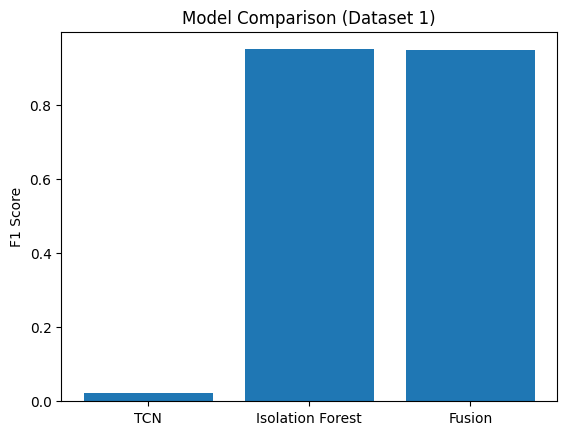

In [120]:
import matplotlib.pyplot as plt

models = ["TCN", "Isolation Forest", "Fusion"]
f1 = [0.022, 0.949, 0.947]

plt.figure()
plt.bar(models, f1)
plt.ylabel("F1 Score")
plt.title("Model Comparison (Dataset 1)")
plt.show()